<a href="https://colab.research.google.com/github/tahiyat-rafi/Introduction-to-deep-learning-/blob/main/iris_dataset_project(sklearn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from pandas.plotting import scatter_matrix

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

name=["sepal length","sepal width","petal length","petal width","class"]
dataset=pd.read_csv("iris.data",names=name)


In [ ]:
print(dataset.shape)

(150, 5)


In [ ]:
print(dataset.head(5))

   sepal length  sepal width  petal length  petal width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [ ]:
print(dataset.describe())

       sepal length  sepal width  petal length  petal width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [ ]:
print(dataset.groupby("class").size())

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


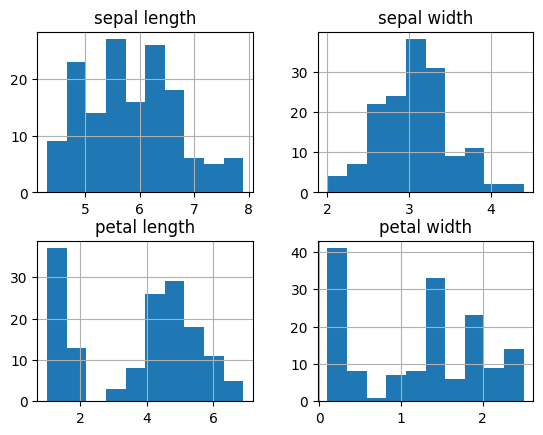

In [ ]:
dataset.hist()
pyplot.show()

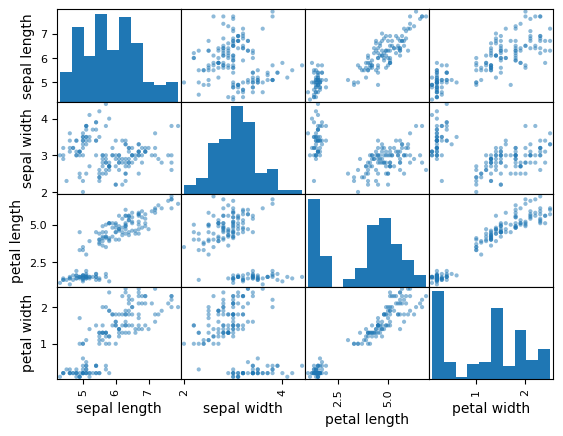

In [ ]:
scatter_matrix(dataset)
pyplot.show()

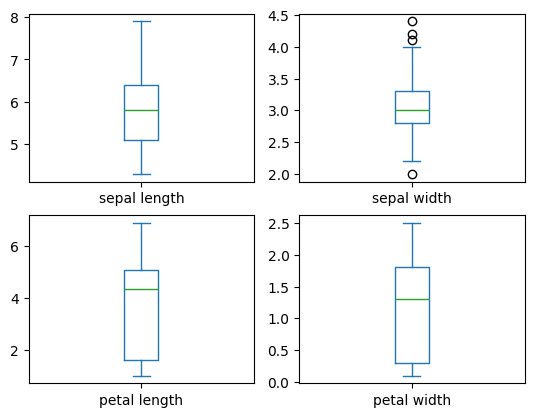

In [ ]:
dataset.plot(kind="box",subplots=True,layout=(2,2),sharex=False,sharey=False)
pyplot.show()

LR:Accuracy=0.967,Standard Deviation=0.041
LDA:Accuracy=0.975,Standard Deviation=0.038
KNC:Accuracy=0.958,Standard Deviation=0.042
DTC:Accuracy=0.967,Standard Deviation=0.041
GNB:Accuracy=0.950,Standard Deviation=0.041
SVC:Accuracy=0.967,Standard Deviation=0.041


/tmp/ipykernel_519/2012381011.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(results,labels=names)


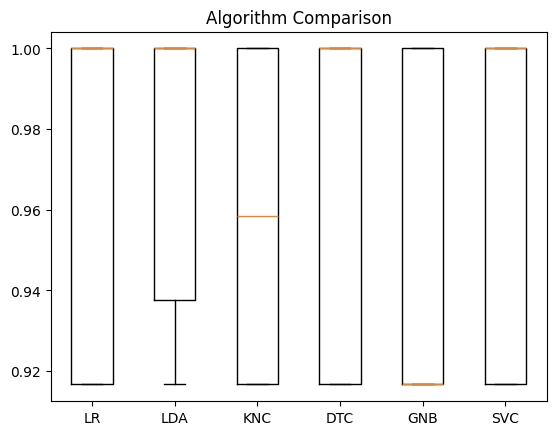


Accuracy score:
0.9666666666666667

Confusion matrix:
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.97        30
      macro avg       0.95      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30



In [ ]:
arr=dataset.values
#dataset.values converts the dataset with pandas features into a plain array
x=arr[:,0:4] #ending index is not included, collects from c0 to c3 (first 4 c's)
y=arr[:,4] #only collects c4 (5th c)
xt,xv,yt,yv=train_test_split(x,y,test_size=.20,random_state=1)

models=[]

models.append(("LR",LogisticRegression()))
models.append(("LDA",LinearDiscriminantAnalysis()))
models.append(("KNC",KNeighborsClassifier()))
models.append(("DTC",DecisionTreeClassifier()))
models.append(("GNB",GaussianNB()))
models.append(("SVC",SVC()))

results=[]
names=[]

for name,model in models:
  kf=KFold(n_splits=10,shuffle=True,random_state=1)
  cv_results=cross_val_score(model,xt,yt,cv=kf,scoring="accuracy")
  results.append(cv_results)
  names.append(name)
  avg=cv_results.mean()
  std=cv_results.std()
  print(f"{name}:Accuracy={avg:.3f},Standard Deviation={std:.3f}")

pyplot.boxplot(results,labels=names)
pyplot.title("Algorithm Comparison")
pyplot.show()

model=DecisionTreeClassifier()
model.fit(xt,yt)
prediction=model.predict(xv)

print("\nAccuracy score:")
print(accuracy_score(yv, prediction))

print("\nConfusion matrix:")
print(confusion_matrix(yv, prediction))

print("\nClassification report:")
print(classification_report(yv, prediction))